In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("yahoo_data.xlsx")

In [3]:
df.sample(5)

,Date,Open,High,Low,Close*,Adj Close**,Volume
1119,"Nov 14, 2018",25388.08,25501.29,24935.82,25080.50,25080.50,384240000
598,"Dec 10, 2020",30032.55,30063.87,29876.82,29999.26,29999.26,325550000
1106,"Dec 04, 2018",25752.56,25773.12,25008.11,25027.07,25027.07,418900000
738,"May 22, 2020",24461.98,24481.64,24294.07,24465.16,24465.16,255660000
669,"Aug 31, 2020",28643.66,28643.66,28363.55,28430.05,28430.05,517320000


In [4]:
df.shape

(1258, 7)

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

Date           0
Open           0
High           0
Low            0
Close*         0
Adj Close**    0
Volume         0
dtype: int64

In [7]:
df = df.drop(columns=('Adj Close**'))

In [8]:
df.sample(5)

,Date,Open,High,Low,Close*,Volume
1051,"Feb 26, 2019",26051.61,26155.29,25966.01,26057.98,257850000
1247,"May 15, 2018",24809.55,24809.55,24629.39,24706.41,301900000
582,"Jan 05, 2021",30204.25,30504.89,30141.78,30391.60,350910000
681,"Aug 13, 2020",27922.51,27986.10,27789.78,27896.72,360160000
173,"Aug 19, 2022",33904.69,33904.69,33627.09,33706.74,293990000


In [9]:
from datetime import datetime

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%b %d, %Y')

# Convert to float (Unix Timestamp)
df['Date_Float'] = df['Date'].astype('int64') / 1e9  # Convert nanoseconds to seconds

print(df)

           Date      Open      High       Low    Close*     Volume  \
0    2023-04-28  33797.43  34104.56  33728.40  34098.16  354310000   
1    2023-04-27  33381.66  33859.75  33374.65  33826.16  343240000   
2    2023-04-26  33596.34  33645.83  33235.85  33301.87  321170000   
3    2023-04-25  33828.34  33875.49  33525.39  33530.83  297880000   
4    2023-04-24  33805.04  33891.15  33726.09  33875.40  252020000   
...         ...       ...       ...       ...       ...        ...   
1253 2018-05-07  24317.66  24479.45  24263.42  24357.32  307670000   
1254 2018-05-04  23865.22  24333.35  23778.87  24262.51  329480000   
1255 2018-05-03  23836.23  23996.15  23531.31  23930.15  389240000   
1256 2018-05-02  24097.63  24185.52  23886.30  23924.98  385350000   
1257 2018-05-01  24117.29  24117.29  23808.19  24099.05  380070000   

        Date_Float  
0     1.682640e+09  
1     1.682554e+09  
2     1.682467e+09  
3     1.682381e+09  
4     1.682294e+09  
...            ...  
1253  1.5256

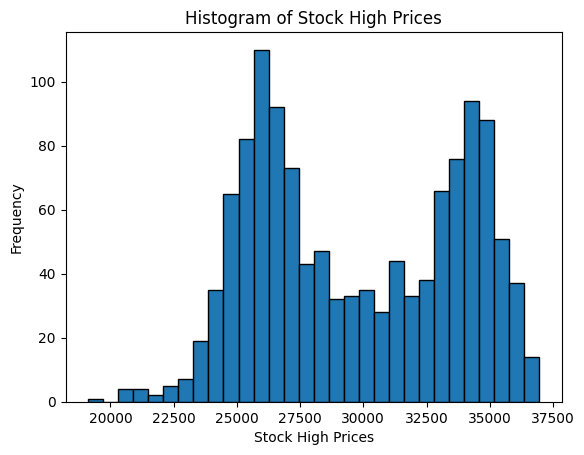

In [11]:
plt.hist(df['High'], bins=30, edgecolor='black')  
plt.xlabel("Stock High Prices")
plt.ylabel("Frequency")
plt.title("Histogram of Stock High Prices")
plt.show()

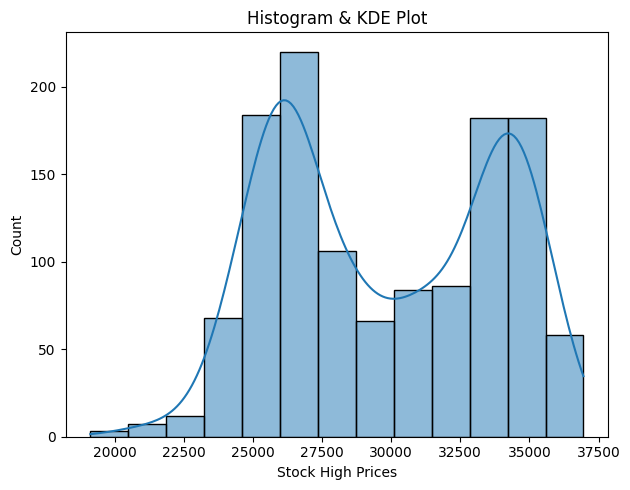

In [12]:
# Set figure size
plt.figure(figsize=(12, 5))

# Histogram & KDE Plot
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
sns.histplot(df['High'],kde=True, edgecolor='black')
plt.xlabel('Stock High Prices')
plt.title('Histogram & KDE Plot')


# Show both plots
plt.tight_layout()
plt.show()

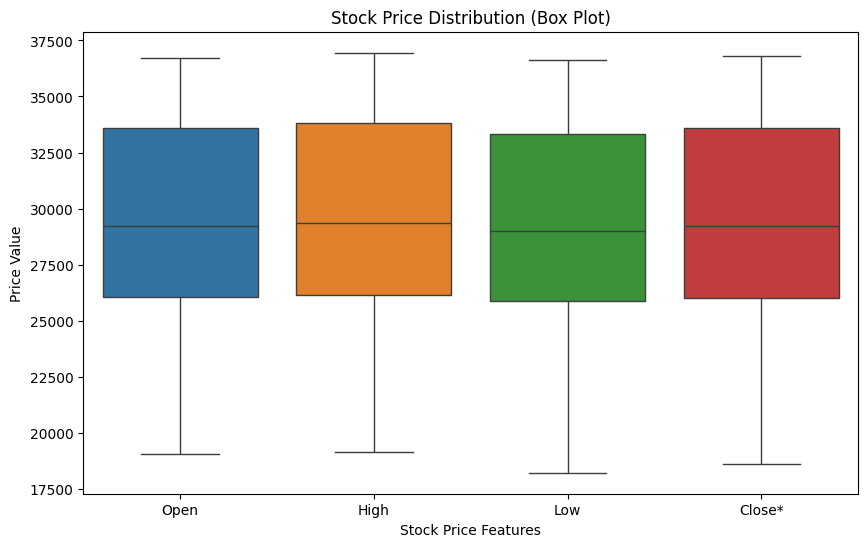

In [13]:
columns = ['Open', 'High', 'Low', 'Close*']

# Creating the boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[columns])

# Adding title and labels
plt.title("Stock Price Distribution (Box Plot)")
plt.xlabel("Stock Price Features")
plt.ylabel("Price Value")

# Show the plot
plt.show()

<Axes: ylabel='High'>

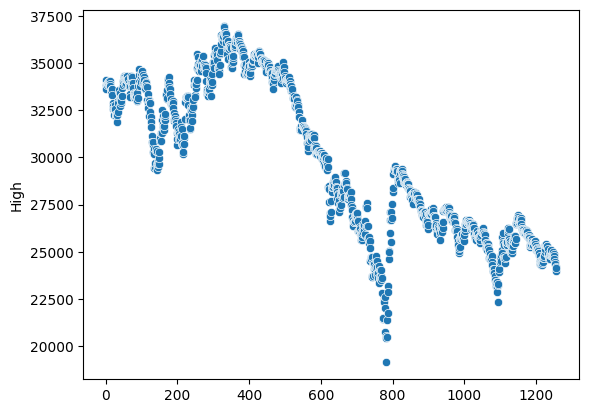

In [14]:
sns.scatterplot(df['High'])

In [15]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [16]:
x_train,x_test,y_train,y_test = train_test_split(df.iloc[:,0:5], df.iloc[:,5:])

In [17]:
x_train['Date'] = x_train['Date'].astype('int64') / 1e9 

In [18]:
x_train

,Date,Open,High,Low,Close*
300,1.644970e+09,34951.83,35042.09,34642.64,34934.27
679,1.597622e+09,27970.05,27999.81,27816.40,27844.91
7,1.681862e+09,33889.83,33957.98,33814.65,33897.01
1194,1.532995e+09,25345.21,25490.98,25345.21,25415.19
663,1.599610e+09,27711.71,28206.21,27704.54,27940.47
...,...,...,...,...,...
1139,1.539734e+09,25705.87,25810.09,25479.16,25706.68
205,1.657066e+09,30957.30,31224.69,30794.84,31037.68
420,1.629936e+09,35449.68,35498.45,35205.10,35213.12
956,1.562890e+09,27139.49,27333.79,27135.45,27332.03


In [19]:
y_train.head()

,Volume,Date_Float
300,294410000,1.644970e+09
679,286860000,1.597622e+09
7,251490000,1.681862e+09
1194,348700000,1.532995e+09
663,460590000,1.599610e+09


In [20]:

from sklearn.linear_model import LinearRegression

In [21]:
lr = LinearRegression()

In [22]:
lr.fit(x_train, y_train)

LinearRegression()

In [23]:
x_test

,Date,Open,High,Low,Close*
685,2020-08-07,27321.68,27456.24,27223.55,27433.48
940,2019-08-05,26259.23,26259.23,25523.38,25717.74
326,2022-01-10,36175.21,36175.21,35639.91,36068.87
1189,2018-08-07,25551.65,25692.72,25551.65,25628.91
475,2021-06-09,34626.16,34654.67,34439.37,34447.14
...,...,...,...,...,...
1004,2019-05-03,26379.14,26534.96,26370.09,26504.95
842,2019-12-23,28491.78,28582.49,28491.78,28551.53
262,2022-04-12,34412.51,34669.97,34102.81,34220.36
715,2020-06-25,25365.22,25769.61,25209.79,25745.60


In [24]:
y_test

,Volume,Date_Float
685,321170000,1.596758e+09
940,422240000,1.564963e+09
326,430680000,1.641773e+09
1189,239910000,1.533600e+09
475,245100000,1.623197e+09
...,...,...
1004,248900000,1.556842e+09
842,223530000,1.577059e+09
262,333510000,1.649722e+09
715,384560000,1.593043e+09


In [28]:
if 'Date' in x_test.columns:
    x_test['Date'] = pd.to_datetime(x_test['Date']).astype('int64') / 1e9  # Convert to float

# Extract the row correctly and reshape
sample = x_test.iloc[5].values.reshape(1, -1)

# Make prediction
prediction = lr.predict(sample)

print(prediction)

[[2.81002943e+08 1.52815680e+09]]


C:\Users\DELL\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


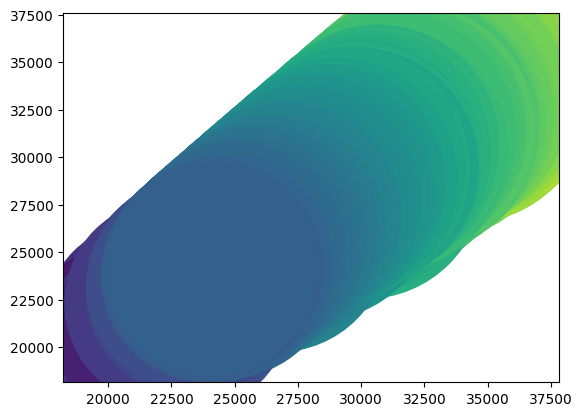

In [29]:
plt.scatter(df['High'], df['Open'], df['Low'], df['Close*'])

In [ ]:
sns.heatmap(df['High'], df['Open'], df['Low'], df['Close*'])

IndexError: Inconsistent shape between the condition and the input (got (1258, 1) and (1258,))